# Evaluation Notebook - Transistor Defect Segmentation
Notebook liczy IoU na danych testowych oraz pokazuje porownania: obraz wejsciowy, predykcja i ground truth.

In [1]:
from pathlib import Path
import importlib.util
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.titlesize'] = 10

In [2]:
def find_project_dir(start: Path) -> Path:
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for c in candidates:
        if (c / 'model.py').exists() and (c / 'transistor').exists():
            return c
    raise FileNotFoundError('Nie znaleziono katalogu projektu (model.py + transistor).')

PROJECT_DIR = find_project_dir(Path.cwd())
TEST_DIR = PROJECT_DIR / 'transistor' / 'test'
GT_DIR = PROJECT_DIR / 'transistor' / 'ground_truth'

spec = importlib.util.spec_from_file_location('model', str(PROJECT_DIR / 'model.py'))
model = importlib.util.module_from_spec(spec)
spec.loader.exec_module(model)

print('Project dir:', PROJECT_DIR)
print('Test dir:', TEST_DIR)
print('GT dir:', GT_DIR)

Project dir: C:\Coding\Sem_6\ZAW\CWP\Transformers\proj01
Test dir: C:\Coding\Sem_6\ZAW\CWP\Transformers\proj01\transistor\test
GT dir: C:\Coding\Sem_6\ZAW\CWP\Transformers\proj01\transistor\ground_truth


In [3]:
CLASSES = ['good', 'bent_lead', 'cut_lead', 'damaged_case', 'misplaced']

def iou(pred: np.ndarray, gt: np.ndarray) -> float:
    p = pred > 0
    g = gt > 0
    union = np.logical_or(p, g).sum()
    if union == 0:
        return 1.0
    inter = np.logical_and(p, g).sum()
    return float(inter / union)

def load_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f'Brak pliku: {path}')
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def load_gt(cls_name: str, image_path: Path, shape_hw: tuple[int, int]) -> np.ndarray:
    if cls_name == 'good':
        return np.zeros(shape_hw, dtype=np.uint8)
    gt_path = GT_DIR / cls_name / f"{image_path.stem}_mask.png"
    gt = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
    if gt is None:
        raise FileNotFoundError(f'Brak maski GT: {gt_path}')
    return gt

def iter_test_images():
    for cls_name in CLASSES:
        cls_dir = TEST_DIR / cls_name
        for p in sorted(cls_dir.glob('*.png')):
            yield cls_name, p

In [4]:
# Pelna ewaluacja testu
scores = {c: [] for c in CLASSES}
details = []

for cls_name, img_path in iter_test_images():
    image = load_rgb(img_path)
    pred = model.predict(image)
    gt = load_gt(cls_name, img_path, image.shape[:2])

    s = iou(pred, gt)
    scores[cls_name].append(s)
    details.append((cls_name, img_path.name, s))

print('=== IoU per class ===')
for c in CLASSES:
    arr = np.array(scores[c], dtype=np.float32)
    print(f'{c:12s} mean={arr.mean():.6f}  min={arr.min():.6f}  max={arr.max():.6f}  n={len(arr)}')

all_scores = np.array([x[2] for x in details], dtype=np.float32)
print('---')
print(f'Overall mean IoU: {all_scores.mean():.6f}')

=== IoU per class ===
good         mean=0.980000  min=0.000000  max=1.000000  n=50
bent_lead    mean=0.000528  min=0.000000  max=0.004752  n=9
cut_lead     mean=0.001727  min=0.000000  max=0.015546  n=9
damaged_case mean=0.006919  min=0.000000  max=0.062275  n=9
misplaced    mean=0.398233  min=0.223264  max=0.489052  n=9
---
Overall mean IoU: 0.612403


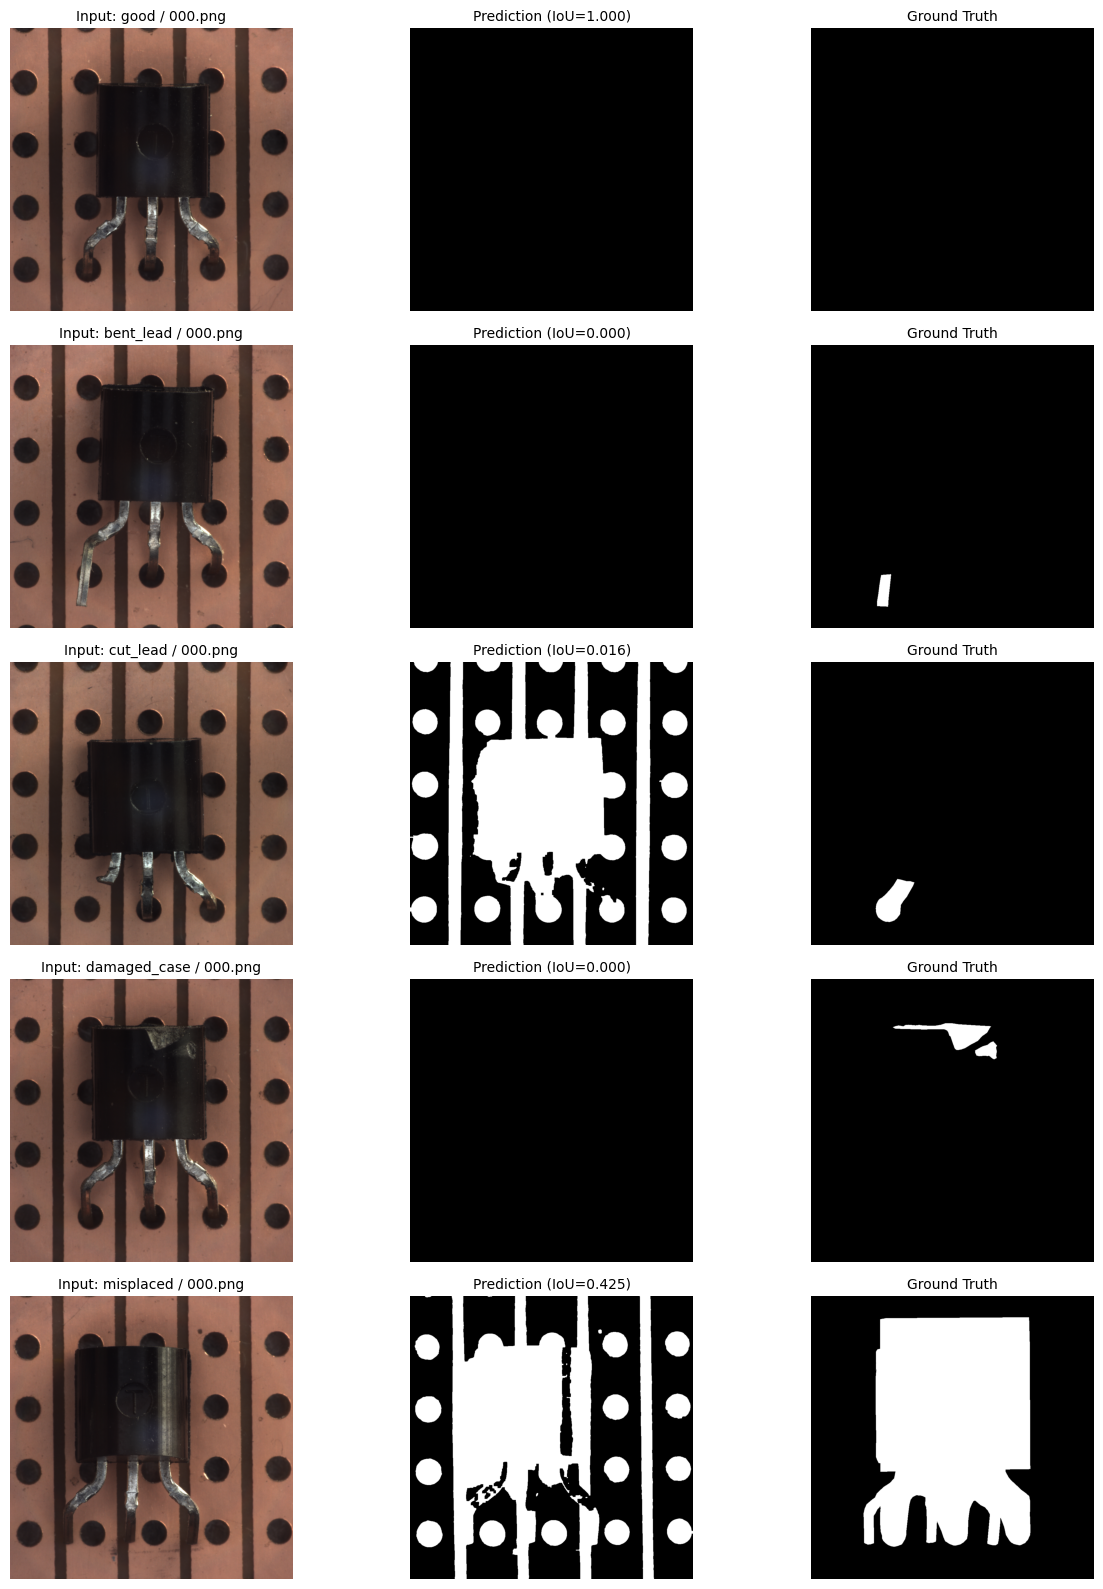

In [5]:
# Kilka przykladow porownawczych
sample_plan = [
    ('good', 0),
    ('bent_lead', 0),
    ('cut_lead', 0),
    ('damaged_case', 0),
    ('misplaced', 0),
]

samples = []
for cls_name, idx in sample_plan:
    files = sorted((TEST_DIR / cls_name).glob('*.png'))
    if not files:
        continue
    idx = min(idx, len(files) - 1)
    samples.append((cls_name, files[idx]))

rows = len(samples)
fig, axes = plt.subplots(rows, 3, figsize=(13, 3.2 * rows))
if rows == 1:
    axes = np.array([axes])

for r, (cls_name, img_path) in enumerate(samples):
    image = load_rgb(img_path)
    pred = model.predict(image)
    gt = load_gt(cls_name, img_path, image.shape[:2])
    score = iou(pred, gt)

    axes[r, 0].imshow(image)
    axes[r, 0].set_title(f'Input: {cls_name} / {img_path.name}')
    axes[r, 0].axis('off')

    axes[r, 1].imshow(pred, cmap='gray', vmin=0, vmax=255)
    axes[r, 1].set_title(f'Prediction (IoU={score:.3f})')
    axes[r, 1].axis('off')

    axes[r, 2].imshow(gt, cmap='gray', vmin=0, vmax=255)
    axes[r, 2].set_title('Ground Truth')
    axes[r, 2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# # Opcjonalnie: zapis porownan do PNG (przydatne do slajdow)
# OUT_DIR = PROJECT_DIR / 'comparison_outputs'
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# for cls_name, img_path in samples:
#     image = load_rgb(img_path)
#     pred = model.predict(image)
#     gt = load_gt(cls_name, img_path, image.shape[:2])

#     h, w = image.shape[:2]
#     canvas = np.zeros((h, 3 * w, 3), dtype=np.uint8)
#     canvas[:, :w] = image
#     canvas[:, w:2*w] = cv2.cvtColor(pred, cv2.COLOR_GRAY2RGB)
#     canvas[:, 2*w:] = cv2.cvtColor(gt, cv2.COLOR_GRAY2RGB)

#     out_path = OUT_DIR / f"{cls_name}_{img_path.stem}_compare.png"
#     cv2.imwrite(str(out_path), cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR))

# print('Zapisano porownania do:', OUT_DIR)